# Generate data from rate model

firing rates, LFP, behavior

In [1]:
import os, scipy.io 
import numpy as np 
# %matplotlib ipympl
import matplotlib.pyplot as plt 
from mpl_toolkits.mplot3d import axes3d

import sys

sys.path.append('/home/nuttidalab/Documents/renee/spikeRNN/analysis/utils')
import load_data as ld

import pickle as pk

2026-04-23 10:58:46.182455: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-04-23 10:58:46.191293: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-04-23 10:58:46.200275: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-04-23 10:58:46.202990: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-04-23 10:58:46.210492: I tensorflow/core/platform/cpu_feature_guar

### check trained models

In [2]:
import glob

def find_files(path, pattern):
    """
    Find all files matching the given glob pattern in the specified path
    Args:
        path (str): path to directory
        pattern (str): glob pattern (e.g., '*.xlsx', '*_sorted_new.mat')
    Returns:
        list of file paths
    """
    return glob.glob(os.path.join(path, pattern))

In [3]:
model_dir = '/home/nuttidalab/Documents/renee/sternberg/interleaved_0.5'

model_names = find_files(model_dir, '*N_1000*.mat')
print(len(model_names))
print(model_names)

7
['/home/nuttidalab/Documents/renee/sternberg/interleaved_0.5/Task_sternberg_N_1000_Jitter_5_3_2026_04_14_044205.mat', '/home/nuttidalab/Documents/renee/sternberg/interleaved_0.5/Task_sternberg_N_1000_Jitter_5_3_2026_04_14_013441.mat', '/home/nuttidalab/Documents/renee/sternberg/interleaved_0.5/Task_sternberg_N_1000_Jitter_5_3_2026_04_14_061957.mat', '/home/nuttidalab/Documents/renee/sternberg/interleaved_0.5/Task_sternberg_N_1000_Jitter_5_3_2026_04_14_014713.mat', '/home/nuttidalab/Documents/renee/sternberg/interleaved_0.5/Task_sternberg_N_1000_Jitter_5_3_2026_04_14_052959.mat', '/home/nuttidalab/Documents/renee/sternberg/interleaved_0.5/Task_sternberg_N_1000_Jitter_5_3_2026_04_14_051628.mat', '/home/nuttidalab/Documents/renee/sternberg/interleaved_0.5/Task_sternberg_N_1000_Jitter_5_3_2026_04_14_025058.mat']


In [20]:
# move models that did not train properly to new folder
import os

new_dir = os.path.join(model_dir, 'old')

if not os.path.exists(new_dir):
    os.makedirs(new_dir)

for i, model_name in enumerate(model_names):
    model_path = os.path.join(model_dir, model_name)
    model_data = scipy.io.loadmat(model_path)
    tr_trials = model_data['tr'][0][0]
    if tr_trials == 39999:
        model_name_nopath = os.path.basename(model_name)
        print(f'moving {model_name_nopath} with {tr_trials} trials')
        os.rename(model_path, os.path.join(new_dir, model_name_nopath))
        

In [ ]:
model_dir = '/home/nuttidalab/Documents/renee/sternberg/interleaved_0.5'

model_names = find_files(model_dir, '*N_1000*.mat')
print(len(model_names))
print(model_names)

['Task_sternberg_N_1000_Jitter_5_3_2026_04_14_023443.mat', 'Task_sternberg_N_1000_Jitter_5_3_2026_04_14_044205.mat', 'Task_sternberg_N_1000_Jitter_5_3_2026_04_14_013441.mat', 'Task_sternberg_N_1000_Jitter_5_3_2026_04_14_051419.mat', 'Task_sternberg_N_1000_Jitter_5_3_2026_04_14_025748.mat', 'Task_sternberg_N_1000_Jitter_5_3_2026_04_13_211235.mat', 'Task_sternberg_N_1000_Jitter_5_3_2026_04_14_063100.mat', 'Task_sternberg_N_1000_Jitter_5_3_2026_04_14_034541.mat', 'Task_sternberg_N_1000_Jitter_5_3_2026_04_14_061957.mat', 'Task_sternberg_N_1000_Jitter_5_3_2026_04_14_021043.mat', 'Task_sternberg_N_1000_Jitter_5_3_2026_04_14_014713.mat', 'Task_sternberg_N_1000_Jitter_5_3_2026_04_14_040516.mat', 'Task_sternberg_N_1000_Jitter_5_3_2026_04_14_052959.mat', 'Task_sternberg_N_1000_Jitter_5_3_2026_04_14_051628.mat', 'Task_sternberg_N_1000_Jitter_5_3_2026_04_14_032453.mat', 'Task_sternberg_N_1000_Jitter_5_3_2026_04_14_025314.mat', 'Task_sternberg_N_1000_Jitter_5_3_2026_04_14_043722.mat', 'Task_sternbe

In [4]:
perfs = []
train_trials = []
for i, model_path in enumerate(model_names):
    # model_path = os.path.join(model_dir, model_name)
    model_name = os.path.basename(model_path)
    model_data = scipy.io.loadmat(model_path)
    perfs.append(model_data['eval_perfs'][0])
    train_trials.append(model_data['tr'][0][0])
    print(f'Model: {model_name}, Test perf: {perfs[i]}, Train trials: {train_trials[i]}')


Model: Task_sternberg_N_1000_Jitter_5_3_2026_04_14_044205.mat, Test perf: [0.96 0.85], Train trials: 23201
Model: Task_sternberg_N_1000_Jitter_5_3_2026_04_14_013441.mat, Test perf: [0.97 0.87], Train trials: 21401
Model: Task_sternberg_N_1000_Jitter_5_3_2026_04_14_061957.mat, Test perf: [0.96 0.93], Train trials: 25301
Model: Task_sternberg_N_1000_Jitter_5_3_2026_04_14_014713.mat, Test perf: [0.96 0.87], Train trials: 25101
Model: Task_sternberg_N_1000_Jitter_5_3_2026_04_14_052959.mat, Test perf: [0.96 0.86], Train trials: 38101
Model: Task_sternberg_N_1000_Jitter_5_3_2026_04_14_051628.mat, Test perf: [0.97 0.91], Train trials: 29901
Model: Task_sternberg_N_1000_Jitter_5_3_2026_04_14_025058.mat, Test perf: [0.96 0.93], Train trials: 29801


### generate data for longer delay (200)

In [4]:
sys.path.append('/home/nuttidalab/Documents/renee/spikeRNN/rate')
import model

Instructions for updating:
non-resource variables are not supported in the long term


In [5]:
def generate_input_stim_sternberg_stims(settings, stim_ids, max_load=3):
    # use stims to specify which channels to activate for the memory set, 
    # instead of randomly choosing them
    # use inf to indicate non-activated channels for lower loads

    T = int(settings['T'])
    stim_on = int(settings['stim_on'])
    stim_dur = int(settings['stim_dur'])
    delay = int(settings['delay'])
    load = (~np.isinf(stim_ids)).sum() - 1 # count number of non-inf values in stim_ids to determine load
    # load = settings['load'] # int for number of items to remember
    
    n_channels = 4

    # Initialize u
    u = np.zeros((n_channels, T))
    
    # Sternberg task
    for i, i_chan in enumerate(stim_ids[:load]):
        i_chan = int(i_chan) # convert from float to int
        if i == 0:
            u[i_chan, stim_on:stim_on+stim_dur] = 1
            ending_idx = stim_on+stim_dur
        else: # 0 bc no separation btwn stimuli
            u[i_chan, ending_idx+0:ending_idx+stim_dur+0] = 1
            ending_idx = ending_idx+stim_dur+0
    
    probe = int(stim_ids[max_load])
    u[probe, ending_idx+delay:ending_idx+delay+stim_dur] = 1
    label = 1 if stim_ids[max_load] in stim_ids[:load] else -1

    return u, label, stim_ids

In [7]:
def generate_input_stim_sternberg_type(settings, max_load=3, match=0):
    # match = 0 for mismatch, 1 for match

    T = settings['T']
    stim_on = settings['stim_on']
    stim_dur = settings['stim_dur']
    delay = settings['delay']
    load = settings['load'] # int for number of items to remember
    
    n_channels = 4
    
    # Initialize stim_ids to keep track of which channels are activated for the memory set
    stim_ids = np.zeros(max_load + 1)
    stim_ids.fill(np.nan)

    # Initialize u
    u = np.zeros((n_channels, T))
    
    # Sternberg task
    stim_chan_idx = np.random.choice(n_channels, load, replace=False)
    stim_ids[:load] = stim_chan_idx
    for i, i_chan in enumerate(stim_chan_idx):
        if i == 0:
            u[i_chan, stim_on:stim_on+stim_dur] = 1
            ending_idx = stim_on+stim_dur
        else: # 0 bc no separation btwn stimuli
            u[i_chan, ending_idx+0:ending_idx+stim_dur+0] = 1
            ending_idx = ending_idx+stim_dur+0
    
    if match == 1:
        # match, so pick a chan from activated chans
        match_chan_idx = np.random.choice(stim_chan_idx, 1)[0]
        u[match_chan_idx, ending_idx+delay:ending_idx+delay+stim_dur] = 1
        stim_ids[max_load] = match_chan_idx # store the match stimulus id in the last position of stim_ids
        label = 1
    elif match == 0:
        # mismatch, so pick a chan from non-activated chans
        non_stim_chan_idx = np.setdiff1d(np.arange(n_channels), stim_chan_idx) # the non-activated channel
        non_match_chan_idx = np.random.choice(non_stim_chan_idx, 1)[0]
        u[non_match_chan_idx, ending_idx+delay:ending_idx+delay+stim_dur] = 1
        stim_ids[max_load] = non_match_chan_idx # store the mismatch stimulus id in the last position of stim_ids
        label = -1
    else:
        raise ValueError('match must be 0 or 1')

    return u, label, stim_ids

#### some scratch work

In [28]:
values = [0, 1, 2, 3]

# All permutations of length 3 (no repeated values)
first_three = list(permutations(values, 3))  # 4P3 = 24

# Combine with column 3 (can repeat anything)
full = [(a, b, c, d) for (a, b, c) in first_three for d in values]

arr = np.array(full)

print(arr.shape)  # (96, 4)
arr

(96, 4)


array([[0, 1, 2, 0],
       [0, 1, 2, 1],
       [0, 1, 2, 2],
       [0, 1, 2, 3],
       [0, 1, 3, 0],
       [0, 1, 3, 1],
       [0, 1, 3, 2],
       [0, 1, 3, 3],
       [0, 2, 1, 0],
       [0, 2, 1, 1],
       [0, 2, 1, 2],
       [0, 2, 1, 3],
       [0, 2, 3, 0],
       [0, 2, 3, 1],
       [0, 2, 3, 2],
       [0, 2, 3, 3],
       [0, 3, 1, 0],
       [0, 3, 1, 1],
       [0, 3, 1, 2],
       [0, 3, 1, 3],
       [0, 3, 2, 0],
       [0, 3, 2, 1],
       [0, 3, 2, 2],
       [0, 3, 2, 3],
       [1, 0, 2, 0],
       [1, 0, 2, 1],
       [1, 0, 2, 2],
       [1, 0, 2, 3],
       [1, 0, 3, 0],
       [1, 0, 3, 1],
       [1, 0, 3, 2],
       [1, 0, 3, 3],
       [1, 2, 0, 0],
       [1, 2, 0, 1],
       [1, 2, 0, 2],
       [1, 2, 0, 3],
       [1, 2, 3, 0],
       [1, 2, 3, 1],
       [1, 2, 3, 2],
       [1, 2, 3, 3],
       [1, 3, 0, 0],
       [1, 3, 0, 1],
       [1, 3, 0, 2],
       [1, 3, 0, 3],
       [1, 3, 2, 0],
       [1, 3, 2, 1],
       [1, 3, 2, 2],
       [1, 3,

In [29]:
from itertools import permutations, product

# Part 1: all permutations of [0,1,2,3]
first_three = list(permutations(values, 3))  # 4P3 = 24

# Combine with column 3 (can repeat anything)
full = [(a, b, c, d) for (a, b, c) in first_three for d in values]

perm_part = np.array(full)

# Part 2: [x, inf, inf, y]
values = [0, 1, 2, 3]
inf = np.inf

middle_inf_part = np.array(
    [[x, inf, inf, y] for x, y in product(values, repeat=2)],
    dtype=float
)

# Combine
result = np.vstack([perm_part, middle_inf_part])

print(result.shape)  # (40, 4)
result

(112, 4)


array([[ 0.,  1.,  2.,  0.],
       [ 0.,  1.,  2.,  1.],
       [ 0.,  1.,  2.,  2.],
       [ 0.,  1.,  2.,  3.],
       [ 0.,  1.,  3.,  0.],
       [ 0.,  1.,  3.,  1.],
       [ 0.,  1.,  3.,  2.],
       [ 0.,  1.,  3.,  3.],
       [ 0.,  2.,  1.,  0.],
       [ 0.,  2.,  1.,  1.],
       [ 0.,  2.,  1.,  2.],
       [ 0.,  2.,  1.,  3.],
       [ 0.,  2.,  3.,  0.],
       [ 0.,  2.,  3.,  1.],
       [ 0.,  2.,  3.,  2.],
       [ 0.,  2.,  3.,  3.],
       [ 0.,  3.,  1.,  0.],
       [ 0.,  3.,  1.,  1.],
       [ 0.,  3.,  1.,  2.],
       [ 0.,  3.,  1.,  3.],
       [ 0.,  3.,  2.,  0.],
       [ 0.,  3.,  2.,  1.],
       [ 0.,  3.,  2.,  2.],
       [ 0.,  3.,  2.,  3.],
       [ 1.,  0.,  2.,  0.],
       [ 1.,  0.,  2.,  1.],
       [ 1.,  0.,  2.,  2.],
       [ 1.,  0.,  2.,  3.],
       [ 1.,  0.,  3.,  0.],
       [ 1.,  0.,  3.,  1.],
       [ 1.,  0.,  3.,  2.],
       [ 1.,  0.,  3.,  3.],
       [ 1.,  2.,  0.,  0.],
       [ 1.,  2.,  0.,  1.],
       [ 1.,  

In [ ]:
result_labels = np.array([1 if row[3] in row[:3] else -1 for row in result])
print(sum(result_labels == 1))  
print(sum(result_labels == -1))  

76
36


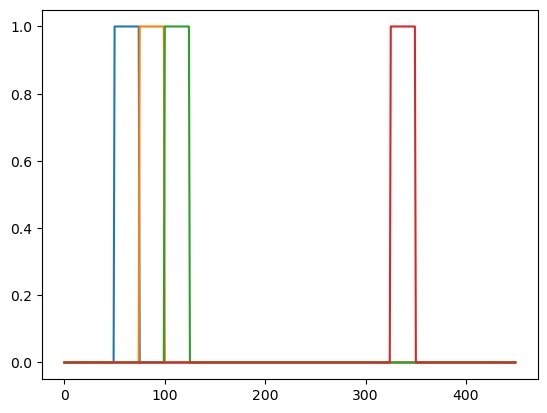

In [44]:
settings = {
        'T': 450, # trial duration (in steps)
        'stim_on': 50, # input stim onset (in steps)
        'stim_dur': 25, # input stim duration (in steps)
        'delay': 200, # delay b/w the two stimuli (in steps)
        'DeltaT': 1, # sampling rate
        'taus': 20, # decay time-constants (in steps)
        'fs': 200,
        'task': 'sternberg', # task name
        'load': 1,
        }
test, _, _ = generate_input_stim_sternberg_stims(settings, result[0,:], max_load=3)
plt.plot(test.T);

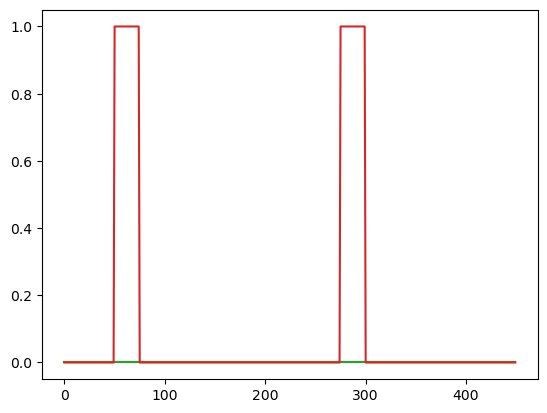

In [45]:
settings = {
        'T': 450, # trial duration (in steps)
        'stim_on': 50, # input stim onset (in steps)
        'stim_dur': 25, # input stim duration (in steps)
        'delay': 200, # delay b/w the two stimuli (in steps)
        'DeltaT': 1, # sampling rate
        'taus': 20, # decay time-constants (in steps)
        'fs': 200,
        'task': 'sternberg', # task name
        'load': 1,
        }
test, _, _ = generate_input_stim_sternberg_stims(settings, result[-1,:], max_load=3)
plt.plot(test.T);

In [8]:
n_trials = 50
eval_amp_threshold = 0.7
matches = [0, 1] # 0 for mismatch, 1 for match
loads = [1, 3] # number of items to remember
model_list = model_names

# delay200
settings = {
        'T': 450, # trial duration (in steps)
        'stim_on': 50, # input stim onset (in steps)
        'stim_dur': 25, # input stim duration (in steps)
        'delay': 200, # delay b/w the two stimuli (in steps)
        'DeltaT': 1, # sampling rate
        'taus': 20, # decay time-constants (in steps)
        'fs': 200,
        'task': 'sternberg', # task name
        'load': 1,
        }

u, label, stim_ids = generate_input_stim_sternberg_type(settings, max_load=np.amax(loads), match=1)
print('Input shape:', u.shape)
print('Label:', label)
print('Stimulus IDs (activated channels for memory set and probe):', stim_ids)

[1, 1, stim_ids]

Input shape: (4, 450)
Label: 1
Stimulus IDs (activated channels for memory set and probe): [ 1. nan nan  1.]


[1, 1, array([ 1., nan, nan,  1.])]

In [11]:
# put all into one array
np.concatenate(([1, 1], stim_ids.flatten()))

array([ 1.,  1.,  1., nan, nan,  1.])

#### run data

In [ ]:
from itertools import permutations, product

def get_all_stim_combos():
    # generate all possible stim combinations for the memory set and probe
    # use inf to indicate non-activated channels for lower loads
    
    values = [0, 1, 2, 3]

    # Part 1: all permutations of [0,1,2,3]
    first_three = list(permutations(values, 3))  # 4P3 = 24

    # Combine with column 3 (can repeat anything)
    full = [(a, b, c, d) for (a, b, c) in first_three for d in values]

    perm_part = np.array(full)

    # Part 2: [x, inf, inf, y]
    inf = np.inf

    middle_inf_part = np.array(
        [[x, inf, inf, y] for x, y in product(values, repeat=2)],
        dtype=float
    )

    # Combine
    result = np.vstack([perm_part, middle_inf_part])
    
    return result

In [ ]:
# conceptually what's happening (don't run, not parallelized):

n_trials = 50
eval_amp_threshold = 0.7
matches = [0, 1] # 0 for mismatch, 1 for match
loads = [1, 3] # number of items to remember
model_list = model_names

# delay200
settings = {
        'T': 450, # trial duration (in steps)
        'stim_on': 50, # input stim onset (in steps)
        'stim_dur': 25, # input stim duration (in steps)
        'delay': 200, # delay b/w the two stimuli (in steps)
        'DeltaT': 1, # sampling rate
        'taus': 20, # decay time-constants (in steps)
        'fs': 200,
        'task': 'sternberg', # task name
        'load': 1,
        }

for n_model, model_path in enumerate(model_list):
    model_name = os.path.basename(model_path)
    output_dir = model_dir + '/' + model_name[:-4] + '/'
    os.makedirs(output_dir, exist_ok=True)
    
    # check if saved neural_dict and bhv_dict already
    if os.path.exists(os.path.join(output_dir, f'neural_dict_delay{settings["delay"]}.pkl')) and os.path.exists(os.path.join(output_dir, f'bhv_dict_delay{settings["delay"]}.pkl')):
        print(f'skipping {model_name}, already saved')
        continue

    neural_dict = {
        'r': [],
        'epsp': []
    }

    bhv_dict = {
        'perf': [],
        'trial_type': []
    }

    for load in loads:
        settings['load'] = load
        resp_onset = settings['stim_on'] + load*settings['stim_dur'] + settings['delay'] + 10
        for match in matches:
            for n in range(n_trials):
                u, label = generate_input_sternberg_type(settings, match=match)
                trial_type = [load, match]
                # trial_type = np.unique(u, axis=1)[np.where(np.unique(u, axis=1) != 0)]

                _, r, o, epsp = model.eval_tf(model_dir=f'{model_dir}/{model_name}', 
                                              settings=settings, u=u, calc_epsp=True)

                neural_dict['r'].append(r)
                neural_dict['epsp'].append(epsp)
                
                if label == 1:
                    if np.max(o[resp_onset:]) > eval_amp_threshold:
                        bhv_dict['perf'].append(1)
                    else:
                        bhv_dict['perf'].append(0)
                else:
                    if np.min(o[resp_onset:]) < -eval_amp_threshold:
                        bhv_dict['perf'].append(1)
                    else:
                        bhv_dict['perf'].append(0)

                bhv_dict['trial_type'].append(trial_type)

    neural_dict['r'] = np.array(neural_dict['r'])
    neural_dict['epsp'] = np.array(neural_dict['epsp'])
    bhv_dict['perf'] = np.array(bhv_dict['perf'])
    
    # save
    with open(os.path.join(output_dir, f'neural_dict_delay{settings["delay"]}.pkl'), 'wb') as f:
        pk.dump(neural_dict, f)

    with open(os.path.join(output_dir, f'bhv_dict_delay{settings["delay"]}.pkl'), 'wb') as f:
        pk.dump(bhv_dict, f)

    print(f"✔ Saved model outputs to {output_dir}")

In [ ]:
# for generating equal numbers of all trial stim combinations -- USE THIS

from concurrent.futures import ProcessPoolExecutor, as_completed


def run_single_model(model_path,
                     model_dir,
                     settings,
                     trial_stims,
                     n_repetitions,
                     eval_amp_threshold):
    # trial_stims is an array of shape (n_combos, n_channels) specifying which channels to activate for the memory set and probe for each trial combo
    # n_repetitions is the number of times to repeat each trial stim combo 

    model_name = os.path.basename(model_path)
    output_dir = os.path.join(model_dir, model_name[:-4])
    os.makedirs(output_dir, exist_ok=True)

    # Skip if already computed
    neural_path = os.path.join(output_dir, f'neural_dict_delay{settings["delay"]}.pkl')
    bhv_path = os.path.join(output_dir, f'bhv_dict_delay{settings["delay"]}.pkl')
    settings_path = os.path.join(output_dir, f'settings_dict_delay{settings["delay"]}.pkl')

    # if os.path.exists(neural_path) and os.path.exists(bhv_path):
    #     print(f'skipping {model_name}, already saved')
    #     return

    neural_dict = {'r': [], 'epsp': []}
    bhv_dict = {'perf': [], 'trial_type': [], 'outputs': []}
    
    max_load = trial_stims.shape[1] - 1

    for stim_ids in trial_stims:

        # compute load from inf mask (same logic as before)
        load = (~np.isinf(stim_ids)).sum() - 1

        local_settings = settings.copy()
        local_settings['load'] = int(load)

        resp_onset = (
            local_settings['stim_on']
            + load * local_settings['stim_dur']
            + local_settings['delay']
            + 10
        )

        u, label, stim_ids_used = generate_input_stim_sternberg_stims(
                local_settings,
                stim_ids,
                max_load=max_load
            )
        
        for _ in range(n_repetitions):

            
            _, r, o, epsp = model.eval_tf(
                model_dir=f'{model_dir}/{model_name}',
                settings=local_settings,
                u=u,
                calc_epsp=True
            )

            neural_dict['r'].append(r)
            neural_dict['epsp'].append(epsp)

            # Behavioral performance
            if label == 1:
                perf = int(np.max(o[resp_onset:]) > eval_amp_threshold)
            else:
                perf = int(np.min(o[resp_onset:]) < -eval_amp_threshold)

            bhv_dict['perf'].append(perf)
            bhv_dict['trial_type'].append(np.concatenate(([load, label], stim_ids.flatten())))  # include stim_ids in trial_type for later analysis
            bhv_dict['outputs'].append(o)
                
    # Convert to arrays
    neural_dict['r'] = np.array(neural_dict['r'])
    neural_dict['epsp'] = np.array(neural_dict['epsp'])
    bhv_dict['perf'] = np.array(bhv_dict['perf'])
    bhv_dict['outputs'] = np.array(bhv_dict['outputs'])

    # Save results
    with open(neural_path, 'wb') as f:
        pk.dump(neural_dict, f)

    with open(bhv_path, 'wb') as f:
        pk.dump(bhv_dict, f)
        
    with open(settings_path, 'wb') as f:
        pk.dump(local_settings, f)

    print(f"✔ Saved model outputs to {output_dir}")


if __name__ == "__main__":

    n_trials = 50
    eval_amp_threshold = 0.7
    trial_stims = get_all_stim_combos()
    n_repetitions = 3 # number of times to repeat each trial stim combo
    model_list = model_names

    settings = {
        'T': 450,
        'stim_on': 50,
        'stim_dur': 25,
        'delay': 200,
        'DeltaT': 1,
        'taus': 20,
        'fs': 200,
        'task': 'sternberg',
        'load': 1,
    }

    # Adjust max_workers to your CPU count
    with ProcessPoolExecutor() as executor:

        futures = [
            executor.submit(
                run_single_model,
                model_path,
                model_dir,
                settings,
                trial_stims,
                n_repetitions,
                eval_amp_threshold
            )
            for model_path in model_list
        ]

        for future in as_completed(futures):
            future.result()  # raises exceptions if any

In [ ]:
# 4/22/26: NOT USING THIS CURRENTLY
# for randomly generating trials, balancing the number of match and mismatch trials per load
from concurrent.futures import ProcessPoolExecutor, as_completed


def run_single_model(model_path,
                     model_dir,
                     settings,
                     n_trials,
                     loads,
                     matches,
                     eval_amp_threshold):

    model_name = os.path.basename(model_path)
    output_dir = os.path.join(model_dir, model_name[:-4])
    os.makedirs(output_dir, exist_ok=True)

    # Skip if already computed
    neural_path = os.path.join(output_dir, f'neural_dict_delay{settings["delay"]}.pkl')
    bhv_path = os.path.join(output_dir, f'bhv_dict_delay{settings["delay"]}.pkl')
    settings_path = os.path.join(output_dir, f'settings_dict_delay{settings["delay"]}.pkl')

    if os.path.exists(neural_path) and os.path.exists(bhv_path):
        print(f'skipping {model_name}, already saved')
        return

    neural_dict = {'r': [], 'epsp': []}
    bhv_dict = {'perf': [], 'trial_type': [], 'outputs': []}

    for load in loads:
        local_settings = settings.copy()  # avoid shared-state issues
        local_settings['load'] = load

        resp_onset = (
            local_settings['stim_on']
            + load * local_settings['stim_dur']
            + local_settings['delay']
            + 10
        )

        for match in matches:
            for _ in range(n_trials):

                u, label, stim_ids = generate_input_stim_sternberg_type(local_settings, max_load=np.amax(loads), match=match)

                _, r, o, epsp = model.eval_tf(
                    model_dir=f'{model_dir}/{model_name}',
                    settings=local_settings,
                    u=u,
                    calc_epsp=True
                )

                neural_dict['r'].append(r)
                neural_dict['epsp'].append(epsp)

                # Behavioral performance
                if label == 1:
                    perf = int(np.max(o[resp_onset:]) > eval_amp_threshold)
                else:
                    perf = int(np.min(o[resp_onset:]) < -eval_amp_threshold)

                bhv_dict['perf'].append(perf)
                bhv_dict['trial_type'].append(np.concatenate(([load, match], stim_ids.flatten())))  # include stim_ids in trial_type for later analysis
                bhv_dict['outputs'].append(o)
                
    # Convert to arrays
    neural_dict['r'] = np.array(neural_dict['r'])
    neural_dict['epsp'] = np.array(neural_dict['epsp'])
    bhv_dict['perf'] = np.array(bhv_dict['perf'])
    bhv_dict['outputs'] = np.array(bhv_dict['outputs'])

    # Save results
    with open(neural_path, 'wb') as f:
        pk.dump(neural_dict, f)

    with open(bhv_path, 'wb') as f:
        pk.dump(bhv_dict, f)
        
    with open(settings_path, 'wb') as f:
        pk.dump(local_settings, f)

    print(f"✔ Saved model outputs to {output_dir}")


if __name__ == "__main__":

    n_trials = 50
    eval_amp_threshold = 0.7
    matches = [0, 1]
    loads = [1, 3]
    model_list = model_names

    settings = {
        'T': 450,
        'stim_on': 50,
        'stim_dur': 25,
        'delay': 200,
        'DeltaT': 1,
        'taus': 20,
        'fs': 200,
        'task': 'sternberg',
        'load': 1,
    }

    # Adjust max_workers to your CPU count
    with ProcessPoolExecutor() as executor:

        futures = [
            executor.submit(
                run_single_model,
                model_path,
                model_dir,
                settings,
                n_trials,
                loads,
                matches,
                eval_amp_threshold
            )
            for model_path in model_list
        ]

        for future in as_completed(futures):
            future.result()  # raises exceptions if any

✔ Saved model outputs to /home/nuttidalab/Documents/renee/sternberg/interleaved_0.5/Task_sternberg_N_1000_Jitter_5_3_2026_04_14_013441
✔ Saved model outputs to /home/nuttidalab/Documents/renee/sternberg/interleaved_0.5/Task_sternberg_N_1000_Jitter_5_3_2026_04_14_014713
✔ Saved model outputs to /home/nuttidalab/Documents/renee/sternberg/interleaved_0.5/Task_sternberg_N_1000_Jitter_5_3_2026_04_14_051628
✔ Saved model outputs to /home/nuttidalab/Documents/renee/sternberg/interleaved_0.5/Task_sternberg_N_1000_Jitter_5_3_2026_04_14_044205
✔ Saved model outputs to /home/nuttidalab/Documents/renee/sternberg/interleaved_0.5/Task_sternberg_N_1000_Jitter_5_3_2026_04_14_025058
✔ Saved model outputs to /home/nuttidalab/Documents/renee/sternberg/interleaved_0.5/Task_sternberg_N_1000_Jitter_5_3_2026_04_14_052959
✔ Saved model outputs to /home/nuttidalab/Documents/renee/sternberg/interleaved_0.5/Task_sternberg_N_1000_Jitter_5_3_2026_04_14_061957


### make some quick behavior plots

In [7]:
colors = ['#49BEA3', '#6E439A']

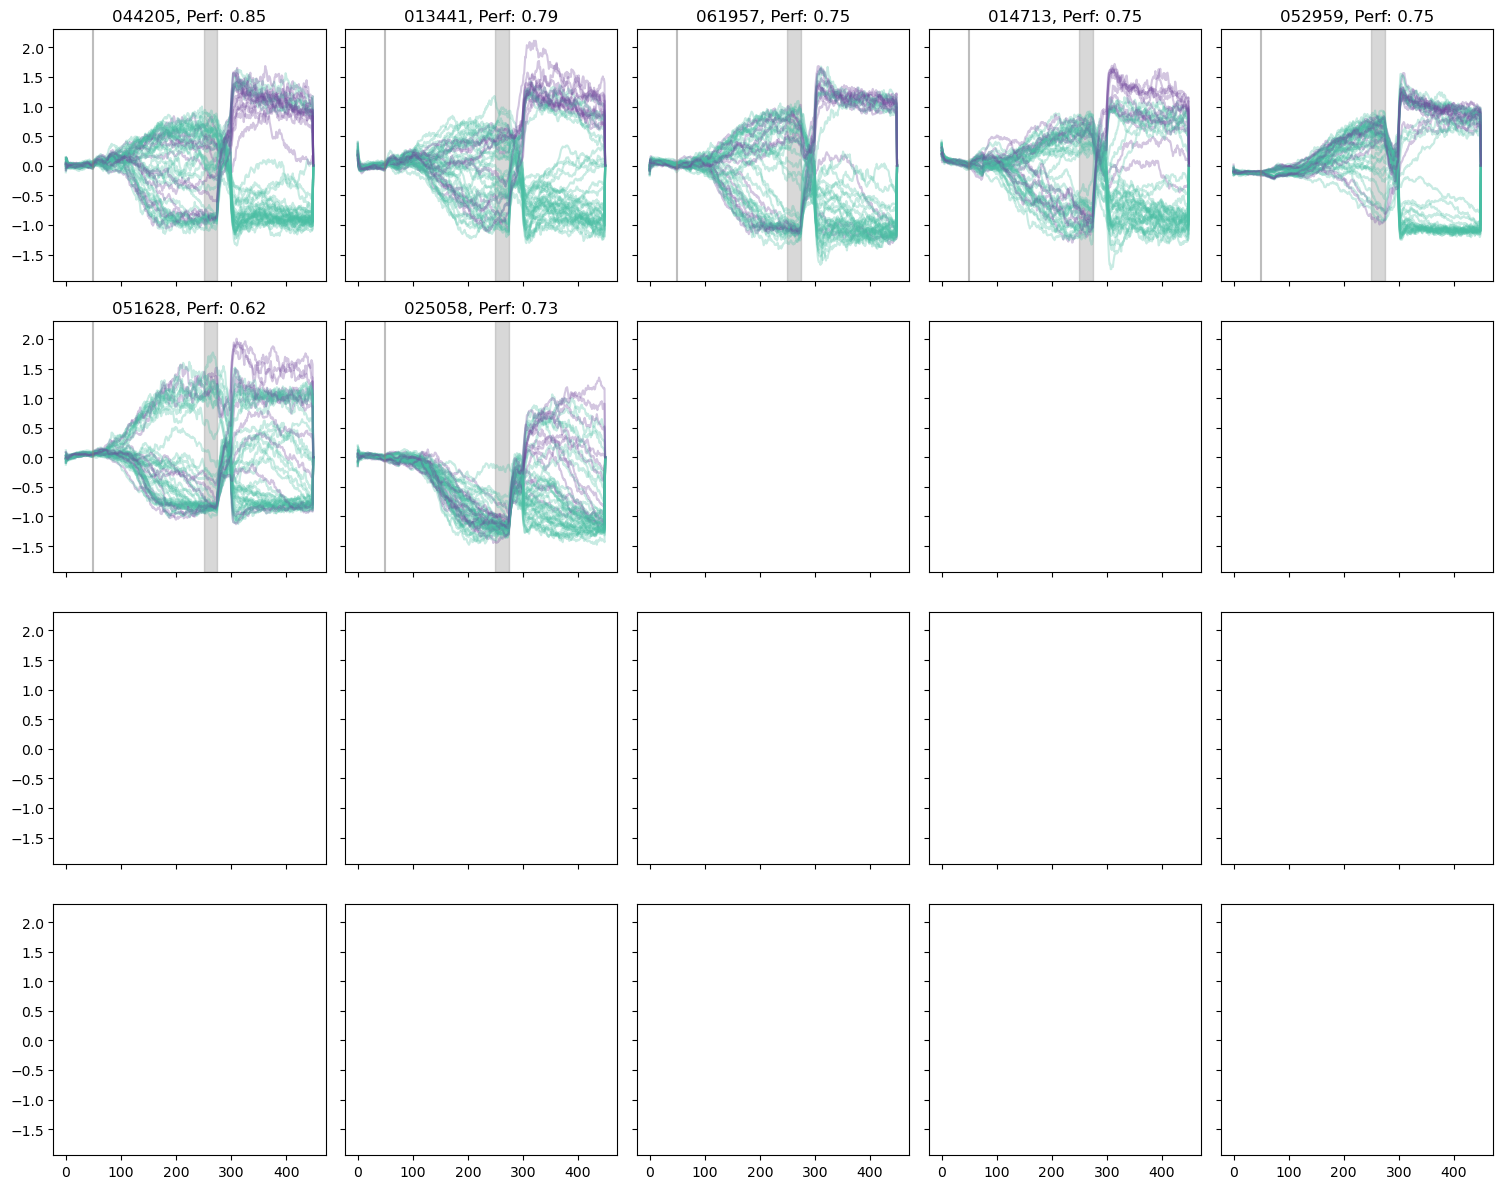

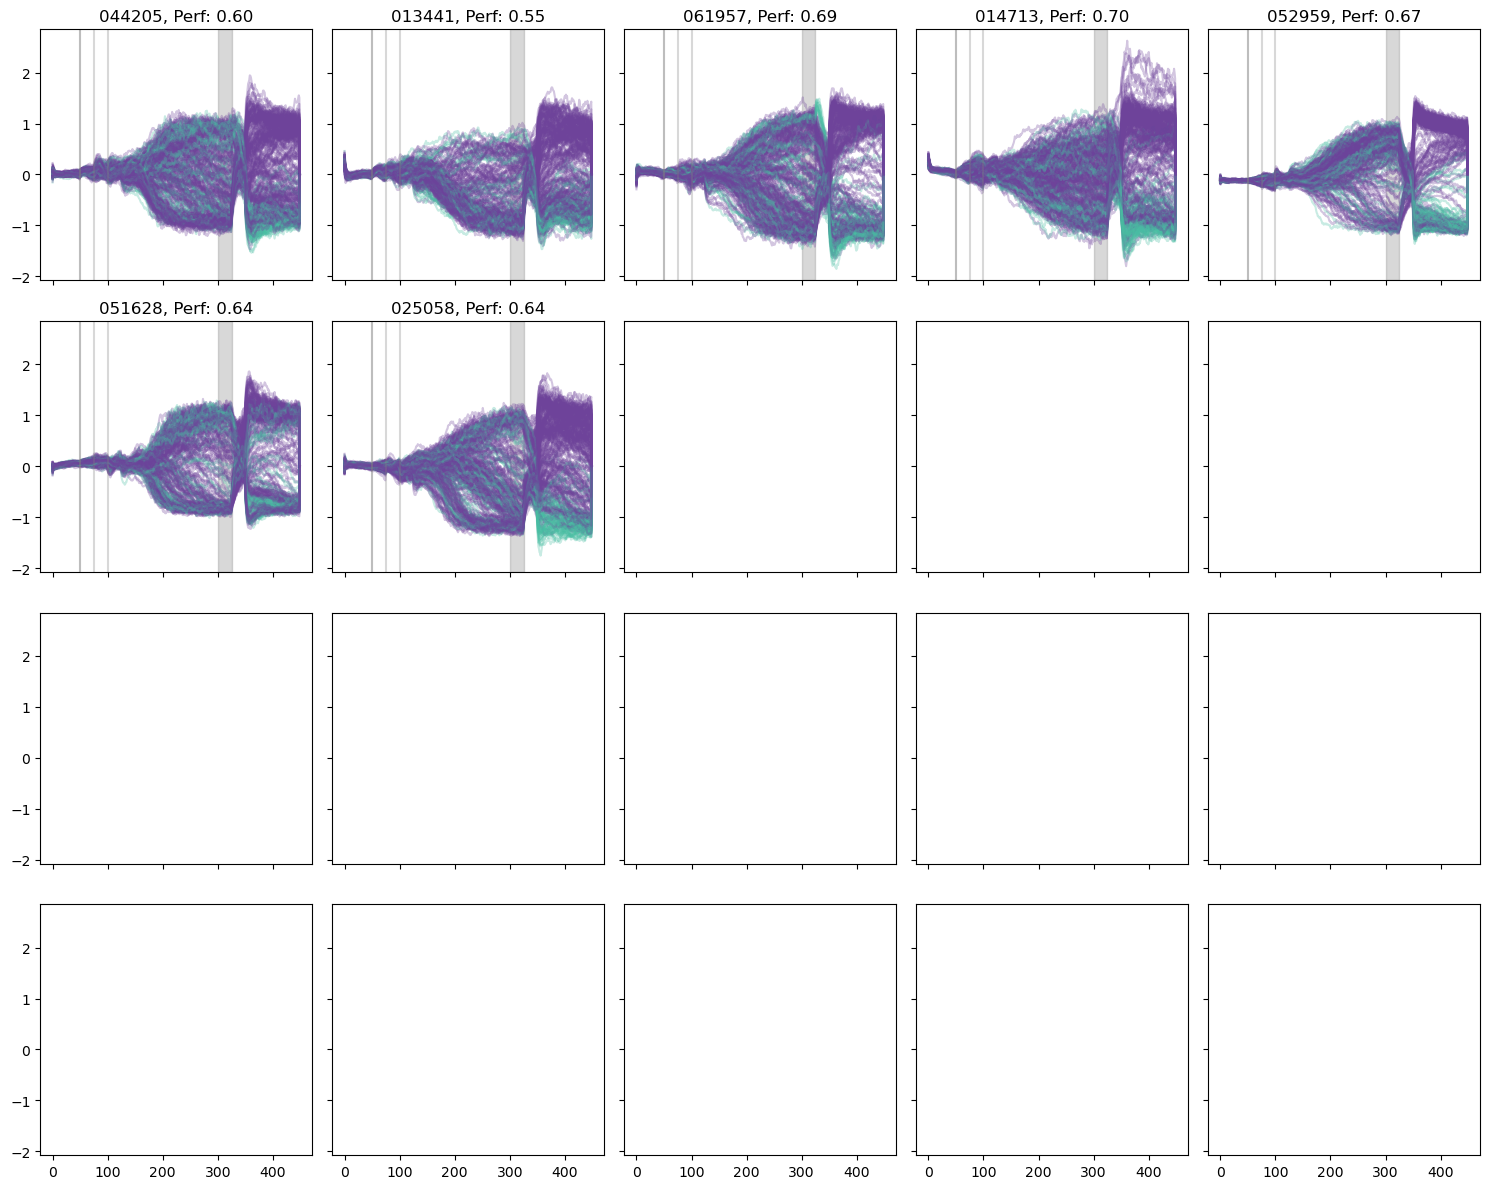

In [8]:
# plot output for each model

settings = {
        'T': 450,
        'stim_on': 50,
        'stim_dur': 25,
        'delay': 200,
        'DeltaT': 1,
        'taus': 20,
        'fs': 200,
        'task': 'sternberg',
        'load': 1,
    }


for k, load in enumerate([1, 3]):
    fig, axs = plt.subplots(4, 5, figsize=(15,12), sharex=True, sharey=True)
    axs = axs.flatten()
    test_perfs = []
    for i, model_path in enumerate(model_names):
        model_name = os.path.basename(model_path)
        output_dir = model_dir + '/' + model_name[:-4] + '/'
        try:
            with open(os.path.join(output_dir, f'bhv_dict_delay{settings["delay"]}.pkl'), 'rb') as f:
                bhv_dict = pk.load(f)
            with open(os.path.join(output_dir, f'settings_dict_delay{settings["delay"]}.pkl'), 'rb') as f:
                settings = pk.load(f)
        except:
            print(f'No data for {model_name}, skipping')
            continue
        
        this_load_idx = np.where(np.array(bhv_dict['trial_type'])[:,0] == load)[0]
        for n in this_load_idx:
             axs[i].plot(bhv_dict['outputs'][n], color=colors[int(bhv_dict['trial_type'][n][1] == 1)], alpha=0.3)
        
        axs[i].set_title(f'{model_name[-10:-4]}, Perf: {np.mean(bhv_dict["perf"][this_load_idx]):.2f}')
        test_perfs.append(np.mean(bhv_dict['perf']))
        stim1_on = settings['stim_on']
        axs[i].axvline(stim1_on, color='gray', alpha=0.3)
        for n in range(load):
            stim_on = settings['stim_on'] + n*settings['stim_dur']
            axs[i].axvline(stim_on, color='gray', alpha=0.3)
        axs[i].axvspan(stim_on + settings['delay'], stim_on + settings['delay'] + settings['stim_dur'], color='gray', alpha=0.3)
    plt.tight_layout()
    plt.show()

In [9]:
test_perfs = []
loads = [1, 3]
for i, model_path in enumerate(model_names):
    model_name = os.path.basename(model_path)
    output_dir = model_dir + '/' + model_name[:-4] + '/'
    
    with open(os.path.join(output_dir, f'settings_dict_delay{200}.pkl'), 'rb') as f:
        settings = pk.load(f)
    with open(os.path.join(output_dir, f'bhv_dict_delay{settings["delay"]}.pkl'), 'rb') as f:
        bhv_dict = pk.load(f)
    
    load_perfs = np.zeros(2)
    for n, load in enumerate(loads):
        this_load_idx = np.where(np.array(bhv_dict['trial_type'])[:,0] == load)[0]
        load_perfs[n] = np.mean(bhv_dict['perf'][this_load_idx])
    test_perfs.append(load_perfs)
    
test_perfs = np.array(test_perfs)
test_perfs

array([[0.85416667, 0.60069444],
       [0.79166667, 0.55208333],
       [0.75      , 0.69097222],
       [0.75      , 0.70486111],
       [0.75      , 0.66666667],
       [0.625     , 0.63541667],
       [0.72916667, 0.63541667]])

In [10]:
perfs = []
train_trials = []
for i, model_path in enumerate(model_names):
    # model_path = os.path.join(model_dir, model_name)
    model_name = os.path.basename(model_path)
    model_data = scipy.io.loadmat(model_path)
    perfs.append(model_data['eval_perfs'][0])
    train_trials.append(model_data['tr'][0][0])
    print(f'Model: {model_name}, Test perf: {perfs[i]}, Train trials: {train_trials[i]}')


Model: Task_sternberg_N_1000_Jitter_5_3_2026_04_14_044205.mat, Test perf: [0.96 0.85], Train trials: 23201
Model: Task_sternberg_N_1000_Jitter_5_3_2026_04_14_013441.mat, Test perf: [0.97 0.87], Train trials: 21401
Model: Task_sternberg_N_1000_Jitter_5_3_2026_04_14_061957.mat, Test perf: [0.96 0.93], Train trials: 25301
Model: Task_sternberg_N_1000_Jitter_5_3_2026_04_14_014713.mat, Test perf: [0.96 0.87], Train trials: 25101
Model: Task_sternberg_N_1000_Jitter_5_3_2026_04_14_052959.mat, Test perf: [0.96 0.86], Train trials: 38101
Model: Task_sternberg_N_1000_Jitter_5_3_2026_04_14_051628.mat, Test perf: [0.97 0.91], Train trials: 29901
Model: Task_sternberg_N_1000_Jitter_5_3_2026_04_14_025058.mat, Test perf: [0.96 0.93], Train trials: 29801


/tmp/ipykernel_620504/571410904.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axs[i].boxplot([perfs[:,i], test_perfs[:,i]], labels=['Delay=50', 'Delay=200'])
/tmp/ipykernel_620504/571410904.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axs[i].boxplot([perfs[:,i], test_perfs[:,i]], labels=['Delay=50', 'Delay=200'])
/tmp/ipykernel_620504/571410904.py:23: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axs[2].boxplot([perfs[:,0], perfs[:,1]], labels=['Load 1', 'Load 3'])
/tmp/ipykernel_620504/571410904.py:32: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since 

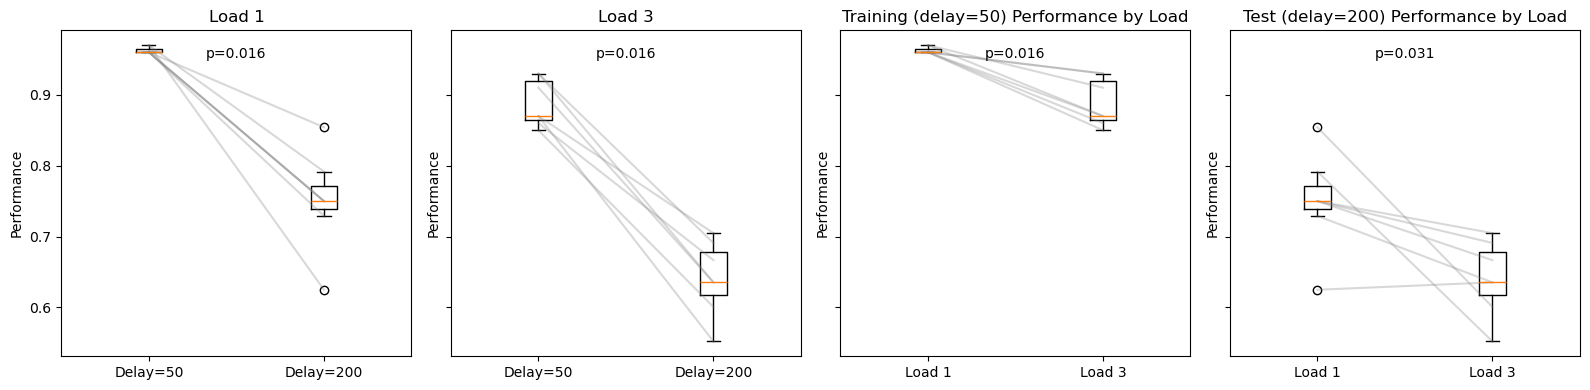

In [11]:
# plot behavior boxplots
perfs = np.array(perfs)
test_perfs = np.array(test_perfs)

fig, axs = plt.subplots(1, 4, figsize=(16,4), sharey=True)

# first compare Training and Test performance for each load
for i, load in enumerate(loads):
    axs[i].boxplot([perfs[:,i], test_perfs[:,i]], labels=['Delay=50', 'Delay=200'])
    axs[i].set_title(f'Load {load}')
    axs[i].set_ylabel('Performance')
    
    # include stats
    from scipy.stats import wilcoxon
    stat, p = wilcoxon(perfs[:,i], test_perfs[:,i])
    axs[i].text(0.5, 0.95, f'p={p:.3f}', transform=axs[i].transAxes, ha='center', va='top')
    
    # gray lines for individual models
    for j in range(perfs.shape[0]):
        axs[i].plot([1, 2], [perfs[j,i], test_perfs[j,i]], color='gray', alpha=0.3)

# next compare training performance across loads
axs[2].boxplot([perfs[:,0], perfs[:,1]], labels=['Load 1', 'Load 3'])
axs[2].set_title('Training (delay=50) Performance by Load')
axs[2].set_ylabel('Performance')
stat, p = wilcoxon(perfs[:,0], perfs[:,1])
axs[2].text(0.5, 0.95, f'p={p:.3f}', transform=axs[2].transAxes, ha='center', va='top')
for j in range(perfs.shape[0]):
    axs[2].plot([1, 2], [perfs[j,0], perfs[j,1]], color='gray', alpha=0.3)

# next compare test performance across loads
axs[3].boxplot([test_perfs[:,0], test_perfs[:,1]], labels=['Load 1', 'Load 3'])
axs[3].set_title('Test (delay=200) Performance by Load')
axs[3].set_ylabel('Performance')
stat, p = wilcoxon(test_perfs[:,0], test_perfs[:,1])
axs[3].text(0.5, 0.95, f'p={p:.3f}', transform=axs[3].transAxes, ha='center', va='top')
for j in range(test_perfs.shape[0]):
    axs[3].plot([1, 2], [test_perfs[j,0], test_perfs[j,1]], color='gray', alpha=0.3)

plt.tight_layout()
plt.show()
    

In [12]:
# move models that have delay=200 performance < 0.7 for either load to new folder
new_dir = os.path.join(model_dir, 'low_perf')
if not os.path.exists(new_dir):
    os.makedirs(new_dir)
    
for i, model_name in enumerate(model_names):
    model_path = os.path.join(model_dir, model_name)
    model_name = os.path.basename(model_path)
    output_dir = model_dir + '/' + model_name[:-4] + '/'
    
    with open(os.path.join(output_dir, f'settings_dict_delay{200}.pkl'), 'rb') as f:
        settings = pk.load(f)
    with open(os.path.join(output_dir, f'bhv_dict_delay{settings["delay"]}.pkl'), 'rb') as f:
        bhv_dict = pk.load(f)
    
    load_perfs = np.zeros(2)
    for n, load in enumerate(loads):
        this_load_idx = np.where(np.array(bhv_dict['trial_type'])[:,0] == load)[0]
        load_perfs[n] = np.mean(bhv_dict['perf'][this_load_idx])
    
    if np.any(load_perfs < 0.7):
        print(f'Moving {model_name} with delay=200 perf {load_perfs} to low_perf folder')
#         os.rename(model_path, os.path.join(new_dir, model_name))
        
# print('Done moving low performing models')

Moving Task_sternberg_N_1000_Jitter_5_3_2026_04_14_044205.mat with delay=200 perf [0.85416667 0.60069444] to low_perf folder
Moving Task_sternberg_N_1000_Jitter_5_3_2026_04_14_013441.mat with delay=200 perf [0.79166667 0.55208333] to low_perf folder
Moving Task_sternberg_N_1000_Jitter_5_3_2026_04_14_061957.mat with delay=200 perf [0.75       0.69097222] to low_perf folder
Moving Task_sternberg_N_1000_Jitter_5_3_2026_04_14_052959.mat with delay=200 perf [0.75       0.66666667] to low_perf folder
Moving Task_sternberg_N_1000_Jitter_5_3_2026_04_14_051628.mat with delay=200 perf [0.625      0.63541667] to low_perf folder
Moving Task_sternberg_N_1000_Jitter_5_3_2026_04_14_025058.mat with delay=200 perf [0.72916667 0.63541667] to low_perf folder


In [17]:
# for each model that was moved, move the folder with the same name as the model

lowperf_modelnames = os.listdir(new_dir)

for model_name in lowperf_modelnames:
    model_name_nopath = os.path.basename(model_name)
    folder_name = model_name_nopath[:-4]  # remove .mat extension
    folder_path = os.path.join(model_dir, folder_name)
    if os.path.exists(folder_path):
        print(f'moving folder {folder_name}')
        os.rename(folder_path, os.path.join(new_dir, folder_name))

moving folder Task_sternberg_N_1000_Jitter_5_3_2026_04_14_023443
moving folder Task_sternberg_N_1000_Jitter_5_3_2026_04_14_051419
moving folder Task_sternberg_N_1000_Jitter_5_3_2026_04_14_025748
moving folder Task_sternberg_N_1000_Jitter_5_3_2026_04_13_211235
moving folder Task_sternberg_N_1000_Jitter_5_3_2026_04_14_063100
moving folder Task_sternberg_N_1000_Jitter_5_3_2026_04_14_034541
moving folder Task_sternberg_N_1000_Jitter_5_3_2026_04_14_021043
moving folder Task_sternberg_N_1000_Jitter_5_3_2026_04_14_040516
moving folder Task_sternberg_N_1000_Jitter_5_3_2026_04_14_032453
moving folder Task_sternberg_N_1000_Jitter_5_3_2026_04_14_025314
moving folder Task_sternberg_N_1000_Jitter_5_3_2026_04_14_043722
moving folder Task_sternberg_N_1000_Jitter_5_3_2026_04_14_031912
moving folder Task_sternberg_N_1000_Jitter_5_3_2026_04_14_044339


In [14]:
# get the remaining models

model_dir = '/home/nuttidalab/Documents/renee/sternberg/interleaved_0.5'

model_names = find_files(model_dir, '*N_1000*.mat')
print(len(model_names))
print(model_names)


7
['/home/nuttidalab/Documents/renee/sternberg/interleaved_0.5/Task_sternberg_N_1000_Jitter_5_3_2026_04_14_044205.mat', '/home/nuttidalab/Documents/renee/sternberg/interleaved_0.5/Task_sternberg_N_1000_Jitter_5_3_2026_04_14_013441.mat', '/home/nuttidalab/Documents/renee/sternberg/interleaved_0.5/Task_sternberg_N_1000_Jitter_5_3_2026_04_14_061957.mat', '/home/nuttidalab/Documents/renee/sternberg/interleaved_0.5/Task_sternberg_N_1000_Jitter_5_3_2026_04_14_014713.mat', '/home/nuttidalab/Documents/renee/sternberg/interleaved_0.5/Task_sternberg_N_1000_Jitter_5_3_2026_04_14_052959.mat', '/home/nuttidalab/Documents/renee/sternberg/interleaved_0.5/Task_sternberg_N_1000_Jitter_5_3_2026_04_14_051628.mat', '/home/nuttidalab/Documents/renee/sternberg/interleaved_0.5/Task_sternberg_N_1000_Jitter_5_3_2026_04_14_025058.mat']
